# Averaging, Plotting, Testing

**Author:** Noah Mba, noah.mba@fu-berlin.de  
**Date:** August 14, 2026  
**AI Acknowledgements:** Co-authored/Supported by Claude 5 Sonnet  

---
The main purpose of this notebook is to perform the ERP group-level analysis, i.e. plotting ERPs and testing for significant condition differences using cluster-based permutation tests (CBPT).

### 1. Setup and configuration

In [ ]:
# Import modules
import json
import pickle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.stats import spatio_temporal_cluster_1samp_test
from mne.channels import find_ch_adjacency

# Path definitions
project_root = Path.cwd().parent.parent # Notebook lives in 'project/scripts/eeg'
derivatives_dir = project_root / "data"  / "derivatives" 
results_dir = project_root / "results" / "eeg" / "averaging"
results_dir.mkdir(parents=True, exist_ok=True)

# List of preprocessed participants (check 'subjects_processing_stage.xlsx')
subject_ids = [17, 20, 21, 22, 23, 26, 27, 30, 32, 33, 35, 36, 37, 38, 41, 42, 43, 44]
print(len(subject_ids))

18


### 2. Quality control checks
The following two cells allow us to verify the quality of our epoched data:

* 2.1 How many epochs do we have per condition cell?
* 2.2 Can we see the characteristic Visual Evoked Potentials (VEPs) P1, N1, P2 time-locked to stimulus-onset?

#### 2.1 Epochs per Condition
We'll create a plot showing us the number of epochs per condition for each subject.
Then, we'll aggregate the number of epochs over all subjects in a table.

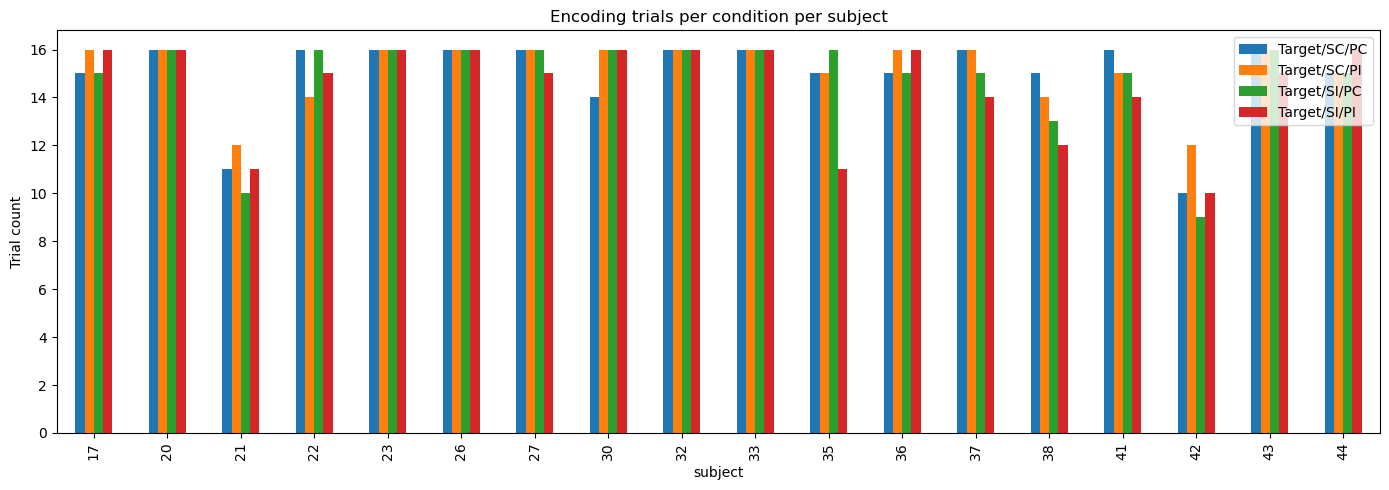

                total    average
condition_cell                  
Target/SC/PC    270.0  15.000000
Target/SC/PI    273.0  15.166667
Target/SI/PC    267.0  14.833333
Target/SI/PI    261.0  14.500000


In [56]:
# List of event ID labels of the four encoding conditions
enc_conditions = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']

# Initialize empty list that'll store one dictionary of the condition count for each subject
count_records = []

# For each subject, load epochs
for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")

    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)

    # Dictionary comprehension: Iterate over four encoding conditions,
    # set 'c' as key and set len(epochs[c]) as value IF the encoding condition
    # is present in epochs.event_id, ELSE set value to NaN
    counts = {c: (len(epochs[c]) if c in epochs.event_id else np.nan) for c in enc_conditions}

    # Dictionary unpacking: count_records is a list of N_subj dictionaries
    count_records.append(
        {"subject": subject_id, **counts} # New dictionairy: first key-value pair is "subject": subject_id
                                          # Then, ** takes all entries from counts and adds them to the new dictionairy 
        ) # For each subject, add the new dictionairy to the list 'count_records'

# Convert count_records into a Pandas dataframe, with subject as index
counts_df = pd.DataFrame(count_records).set_index("subject")
counts_df.to_csv(results_dir / "subj_enc_trial_counts_per_condition.csv")

# Plot trial counts as bar chart
counts_df.plot(kind='bar', figsize=(14, 5), title="Encoding trials per condition per subject")
plt.ylabel("Trial count")
plt.tight_layout()
plt.savefig(results_dir / "subj_enc_trial_counts_per_condition.png", dpi=150)
plt.show()

# Aggregate trial counts across subjects (sum and average)
summary = counts_df.iloc[:, 0:4].agg(['sum', 'mean']).T # Transpose matrix, so that each condition is a row
summary.columns = ['total', 'average']
summary.index.name = 'condition_cell'
print(summary)

summary.to_csv(results_dir / 'agg_enc_trial_counts_per_condition.csv')

In [ ]:
# ==========================================
# STEP 1: Load per-subject cleaned encoding epochs, build evokeds
# ==========================================

# One list per condition/collapsed-factor, one entry per subject
evokeds = {
    'Target/SC/PC': [], 'Target/SC/PI': [], 'Target/SI/PC': [], 'Target/SI/PI': [],
    'SC': [], 'SI': [], 'PC': [], 'PI': [],
}
diff_waves = {'H4_SI_minus_SC': [], 'H5_PI_minus_PC': [], 'H6_SCPI_minus_SIPC': []}

included_subjects, skipped_subjects = [], []

for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")
    if not epochs_path.exists():
        skipped_subjects.append((subject_id, "epochs file not found"))
        continue

    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)

    required = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']
    if not all(cond in epochs.event_id for cond in required):
        skipped_subjects.append((subject_id, "missing one or more conditions"))
        continue

    # Per-condition evokeds (the four 2x2 cell means)
    ev_sc_pc = epochs['Target/SC/PC'].average()
    ev_sc_pi = epochs['Target/SC/PI'].average()
    ev_si_pc = epochs['Target/SI/PC'].average()
    ev_si_pi = epochs['Target/SI/PI'].average()

    # Collapsed main-effect evokeds: average of CELL MEANS, not pooled raw trials —
    # protects each main effect from being confounded by trial-count imbalance
    # in the *other* factor after AutoReject.
    ev_sc = mne.combine_evoked([ev_sc_pc, ev_sc_pi], weights='equal')
    ev_si = mne.combine_evoked([ev_si_pc, ev_si_pi], weights='equal')
    ev_pc = mne.combine_evoked([ev_sc_pc, ev_si_pc], weights='equal')
    ev_pi = mne.combine_evoked([ev_sc_pi, ev_si_pi], weights='equal')

    for cond, ev in [('Target/SC/PC', ev_sc_pc), ('Target/SC/PI', ev_sc_pi),
                      ('Target/SI/PC', ev_si_pc), ('Target/SI/PI', ev_si_pi),
                      ('SC', ev_sc), ('SI', ev_si), ('PC', ev_pc), ('PI', ev_pi)]:
        evokeds[cond].append(ev)

    # Per-subject difference waves — these, not the raw evokeds, are what get tested against zero
    diff_waves['H4_SI_minus_SC'].append(mne.combine_evoked([ev_si, ev_sc], weights=[1, -1]))
    diff_waves['H5_PI_minus_PC'].append(mne.combine_evoked([ev_pi, ev_pc], weights=[1, -1]))
    diff_waves['H6_SCPI_minus_SIPC'].append(mne.combine_evoked([ev_sc_pi, ev_si_pc], weights=[1, -1]))

    included_subjects.append(subject_id)

print(f"Included {len(included_subjects)} / {len(subject_ids)} subjects.")
if skipped_subjects:
    print("Skipped:", skipped_subjects)

Included 18 / 44 subjects.
Skipped: [('01', 'epochs file not found'), ('02', 'epochs file not found'), ('03', 'epochs file not found'), ('04', 'epochs file not found'), ('05', 'epochs file not found'), ('06', 'epochs file not found'), ('07', 'epochs file not found'), ('08', 'epochs file not found'), ('09', 'epochs file not found'), ('10', 'epochs file not found'), ('11', 'epochs file not found'), ('12', 'epochs file not found'), ('13', 'epochs file not found'), ('14', 'epochs file not found'), ('15', 'epochs file not found'), ('16', 'epochs file not found'), ('18', 'epochs file not found'), ('19', 'epochs file not found'), ('24', 'epochs file not found'), ('25', 'epochs file not found'), ('28', 'epochs file not found'), ('29', 'epochs file not found'), ('31', 'epochs file not found'), ('34', 'epochs file not found'), ('39', 'epochs file not found'), ('40', 'epochs file not found')]


#### 2.2 Visual Evoked Potentials
Aggregating over all epochs, do we see the characteristic VEP curve and topography?

The VEP is characterized by two positive deflections (P1, P2) that are separated by a negative deflection (the N1 wave). They can be most prominently observed at occipital/occipito-parietal electrodes, peaking at around 100–130 ms for the P1, and 150–200 ms for the posterior N1 (Luck, 2014).

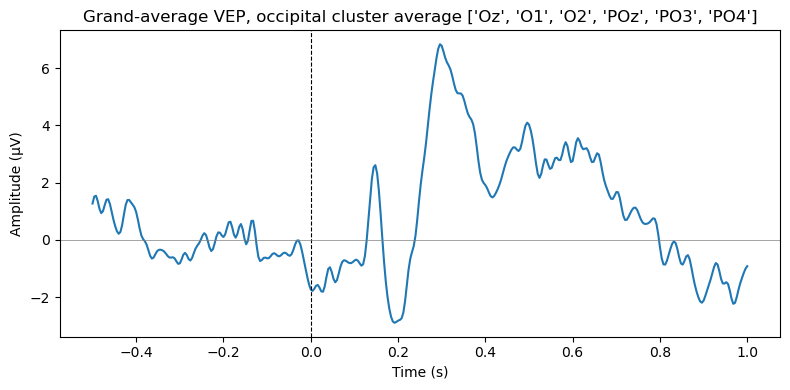

In [57]:
# Grand average across ALL trials
evoked_all = epochs.average()

# --- Create a list of occipital electrodes that should best capture the VEP ---
occipital_picks = ['Oz', 'O1', 'O2', 'POz', 'PO3', 'PO4']
occipital_picks = [ch for ch in occipital_picks if ch in evoked_all.ch_names]

# Average the time-series across the cluster electrodes
occipital_data = evoked_all.copy().pick(occipital_picks).data.mean(axis=0)
times = evoked_all.times

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, occipital_data * 1e6, color='C0')  # converion Volt to microVolt
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Grand-average VEP, occipital cluster average {occipital_picks}')

plt.tight_layout()
plt.savefig('05_veps_occipital_timecourse.png', dpi=150)
plt.show()

In [33]:
# I wonder why the stimulus onset does not correspond with 0 microVolt. Let's check whether the baseline correction worked.
# The average amplitude in the pre-stimulus time window should be zero. Looks good!
evoked_all.copy().crop(tmin=epochs.baseline[0], tmax=epochs.baseline[1]).pick(occipital_picks).data.mean()

np.float64(-6.52045303992957e-16)

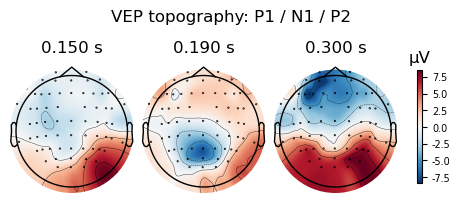

In [34]:
# --- Topoplots at key VEP latencies according to the above plot ---
times = [0.150, 0.190, 0.300]  # seconds
fig = evoked_all.plot_topomap(times=times, ch_type='eeg', show=False)
fig.suptitle('VEP topography: P1 / N1 / P2')
fig.savefig('05_veps_topomap.png', dpi=150)
plt.show()

### 3. Condition-wise comparisons
In this section, we will group the epochs by their four respective encoding conditions. We'll generate descriptive plots and run cluster-based permutations to test whether our experimental manipulations have an influence on the ERPs after target stimulus presentation.

**ERP hypotheses**:
* H4: Main effect of Schema Congruence (SC) vs. Schema Incongruence (SI) Conditions 
* H5: Main effect of Perceptual Congruence (PC) vs. Perceptual Incogruence (PI) Conditions
* H6: Direct contrast of Schema-Congruent/Perceptual Incongruent (SC_PI) vs. Schema-Incongruent/Perceptual-Congruent (SI_PC)

#### 3.1 Build condition-specific evokeds

In [38]:
# ==========================================
# STEP 1: Load per-subject cleaned encoding epochs, build evokeds
# ==========================================

# One list per condition/collapsed-factor, one entry per subject
evokeds = {
    'Target/SC/PC': [], 'Target/SC/PI': [], 'Target/SI/PC': [], 'Target/SI/PI': [],
    'SC': [], 'SI': [], 'PC': [], 'PI': [],
}
diff_waves = {'H4_SI_minus_SC': [], 'H5_PI_minus_PC': [], 'H6_SCPI_minus_SIPC': []}

included_subjects, skipped_subjects = [], []

for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")
    if not epochs_path.exists():
        skipped_subjects.append((subject_id, "epochs file not found"))
        continue

    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)

    required = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']
    if not all(cond in epochs.event_id for cond in required):
        skipped_subjects.append((subject_id, "missing one or more conditions"))
        continue

    ev_sc_pc = epochs['Target/SC/PC'].average()
    ev_sc_pi = epochs['Target/SC/PI'].average()
    ev_si_pc = epochs['Target/SI/PC'].average()
    ev_si_pi = epochs['Target/SI/PI'].average()
    
    # Collapsed main-effect evokeds: average of CELL MEANS, not pooled raw trials —
    # protects each main effect from being confounded by trial-count imbalance
    # in the *other* factor after AutoReject.
    ev_sc = mne.combine_evoked([ev_sc_pc, ev_sc_pi], weights='equal')
    ev_si = mne.combine_evoked([ev_si_pc, ev_si_pi], weights='equal')
    ev_pc = mne.combine_evoked([ev_sc_pc, ev_si_pc], weights='equal')
    ev_pi = mne.combine_evoked([ev_sc_pi, ev_si_pi], weights='equal')
    
    for cond, ev in [('Target/SC/PC', ev_sc_pc), ('Target/SC/PI', ev_sc_pi),
                        ('Target/SI/PC', ev_si_pc), ('Target/SI/PI', ev_si_pi),
                        ('SC', ev_sc), ('SI', ev_si), ('PC', ev_pc), ('PI', ev_pi)]:
        evokeds[cond].append(ev)

    # Per-subject difference waves — these, not the raw evokeds, are what get tested against zero
    diff_waves['H4_SI_minus_SC'].append(mne.combine_evoked([ev_si, ev_sc], weights=[1, -1]))
    diff_waves['H5_PI_minus_PC'].append(mne.combine_evoked([ev_pi, ev_pc], weights=[1, -1]))
    diff_waves['H6_SCPI_minus_SIPC'].append(mne.combine_evoked([ev_sc_pi, ev_si_pc], weights=[1, -1]))

    included_subjects.append(subject_id)

# print(f"Included {len(included_subjects)} / {len(subject_ids)} subjects.")
# if skipped_subjects:
#     print("Skipped:", skipped_subjects)

#### 3.2 Hypothesis testing

In [39]:
# Comment
grand_averages = {cond: mne.grand_average(evs) for cond, evs in evokeds.items()}

# Adjacency defines which electrodes count as "neighbors" for cluster formation —
# a cluster must be contiguous in BOTH time and space (electrode) to count as one cluster.
adjacency, ch_names = find_ch_adjacency(grand_averages['SC'].info, ch_type='eeg')

assert ch_names == grand_averages['SC'].ch_names, (
    "Channel order mismatch between adjacency and evoked data — fix before running the test."
)


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63


In [ ]:
# Comment
alpha = 0.05
n_permutations = 500
random_state = 97

# Comment

def run_cluster_test(diff_evokeds, label):
    """One-sample spatio-temporal cluster permutation test against zero.

    diff_evokeds: list of mne.Evoked, one per subject (the per-subject difference wave).
    """
    # X must be shape (n_subjects, n_times, n_channels) — evoked.data is (n_channels, n_times),
    # so each subject's array gets transposed before stacking.
    X = np.array([ev.data.T for ev in diff_evokeds])

    t_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_1samp_test(
        X,
        threshold=None,      # None -> MNE derives a t-threshold from alpha=0.05 given the df;
                             # switch to threshold_tfce=dict(start=0, step=0.2) for TFCE if you
                             # want to avoid picking a cluster-forming threshold at all
        n_permutations=n_permutations,
        tail=0,              # two-tailed: "significant deviations from zero" in either direction
        adjacency=adjacency,
        n_jobs=1,
        seed=random_state,
        out_type='mask',
        verbose=False,
    )

    sig_clusters = [(i, p) for i, p in enumerate(cluster_p_values) if p < alpha]

    print(f"\n{label}: {len(clusters)} clusters found, {len(sig_clusters)} significant (p < {alpha})")
    for i, p in sig_clusters:
        mask = clusters[i]
        times_idx, ch_idx = np.where(mask)
        t_start = diff_evokeds[0].times[times_idx.min()]
        t_end = diff_evokeds[0].times[times_idx.max()]
        involved_chs = sorted({diff_evokeds[0].ch_names[c] for c in ch_idx})
        print(f"  Cluster {i}: p = {p:.4f}, window = [{t_start:.3f}, {t_end:.3f}] s, "
              f"{len(involved_chs)} channels")

    return {
        't_obs': t_obs, 'clusters': clusters,
        'cluster_p_values': cluster_p_values, 'H0': H0,
        'significant_clusters': sig_clusters,
    }

results = {}
results['H4'] = run_cluster_test(diff_waves['H4_SI_minus_SC'], "H4 (Schematic incongruence)")
results['H5'] = run_cluster_test(diff_waves['H5_PI_minus_PC'], "H5 (Perceptual incongruence)")
results['H6'] = run_cluster_test(diff_waves['H6_SCPI_minus_SIPC'], "H6 (Direct contrast)")


H4 (Schematic incongruence): 89 clusters found, 2 significant (p < 0.05)
  Cluster 30: p = 0.0100, window = [0.244, 0.744] s, 23 channels
  Cluster 73: p = 0.0400, window = [0.336, 1.000] s, 28 channels

H5 (Perceptual incongruence): 111 clusters found, 0 significant (p < 0.05)

H6 (Direct contrast): 105 clusters found, 1 significant (p < 0.05)
  Cluster 96: p = 0.0420, window = [0.368, 0.744] s, 16 channels


#### 3.3 Plot significant clusters

Identifying common channels ...


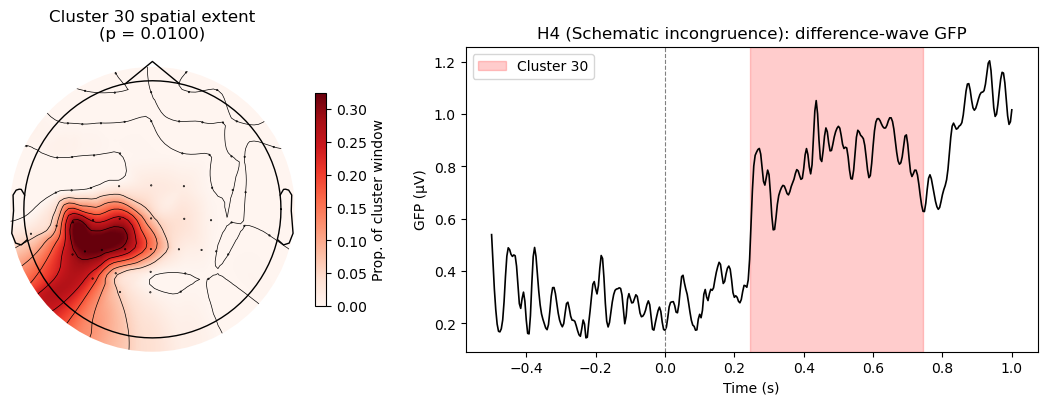

Cluster 30: 23 channels, window [0.244, 0.744] s, p = 0.0100
Identifying common channels ...


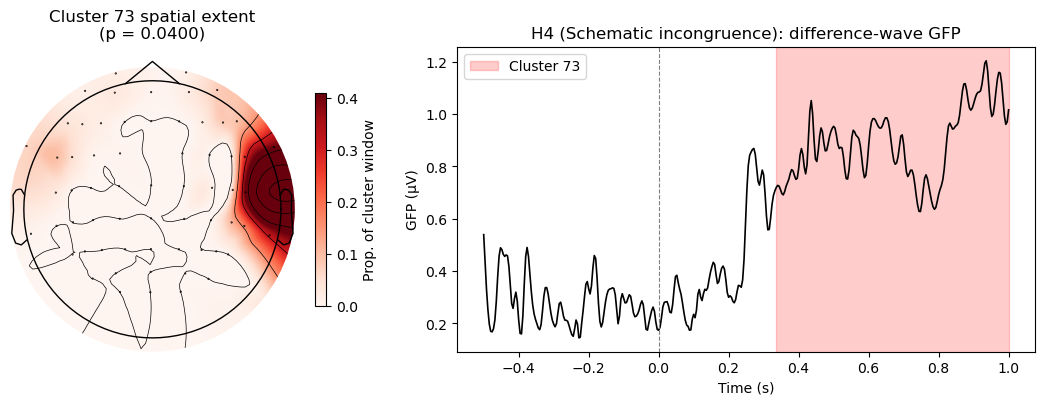

Cluster 73: 28 channels, window [0.336, 1.000] s, p = 0.0400


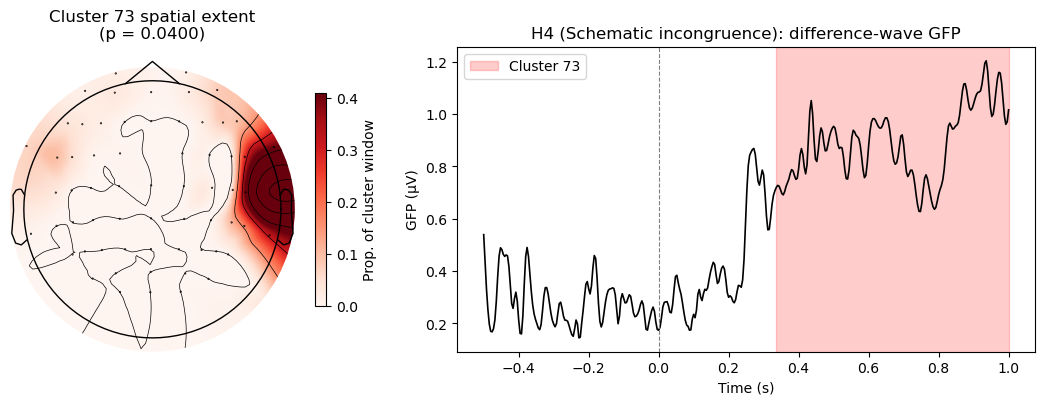

In [42]:
# ==========================================
# 2) Plot a cluster: spatial extent (topomap) + time course (GFP) with window shaded
# ==========================================
def plot_cluster(diff_evokeds, cluster_results, cluster_idx, label):
    """Visualize one cluster from spatio_temporal_cluster_1samp_test output.

    diff_evokeds: list of per-subject mne.Evoked difference waves (same as fed to the test)
    cluster_results: the dict returned by run_cluster_test (has 'clusters', 'cluster_p_values')
    cluster_idx: index into cluster_results['clusters'] (e.g. 30 or 73)
    """
    mask = cluster_results['clusters'][cluster_idx]  # boolean, shape (n_times, n_channels)
    p_val = cluster_results['cluster_p_values'][cluster_idx]

    times = diff_evokeds[0].times
    times_idx, ch_idx = np.where(mask)
    t_start, t_end = times[times_idx.min()], times[times_idx.max()]

    grand_avg = mne.grand_average(diff_evokeds)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [1, 1.4]})

    # Topomap: proportion of the cluster's time window each channel was part of
    chan_involvement = mask.sum(axis=0) / mask.shape[0]
    im, _ = mne.viz.plot_topomap(
        chan_involvement, grand_avg.info, axes=axes[0], show=False,
        cmap='Reds', vlim=(0, chan_involvement.max())
    )
    axes[0].set_title(f'Cluster {cluster_idx} spatial extent\n(p = {p_val:.4f})')
    fig.colorbar(im, ax=axes[0], shrink=0.7, label='Prop. of cluster window')

    # Time course: GFP of the grand-average difference wave, cluster window shaded
    gfp = grand_avg.data.std(axis=0) * 1e6  # V -> µV
    axes[1].plot(times, gfp, color='k', linewidth=1.2)
    axes[1].axvspan(t_start, t_end, color='red', alpha=0.2, label=f'Cluster {cluster_idx}')
    axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('GFP (µV)')
    axes[1].set_title(f'{label}: difference-wave GFP')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'cluster_{label.split()[0]}_{cluster_idx}.png', dpi=150)
    plt.show()

    n_chs = len({c for c in ch_idx})
    print(f"Cluster {cluster_idx}: {n_chs} channels, window [{t_start:.3f}, {t_end:.3f}] s, "
          f"p = {p_val:.4f}")
    return fig


plot_cluster(diff_waves['H4_SI_minus_SC'], results['H4'], 30, "H4 (Schematic incongruence)")
plot_cluster(diff_waves['H4_SI_minus_SC'], results['H4'], 73, "H4 (Schematic incongruence)")



Identifying common channels ...
Identifying common channels ...


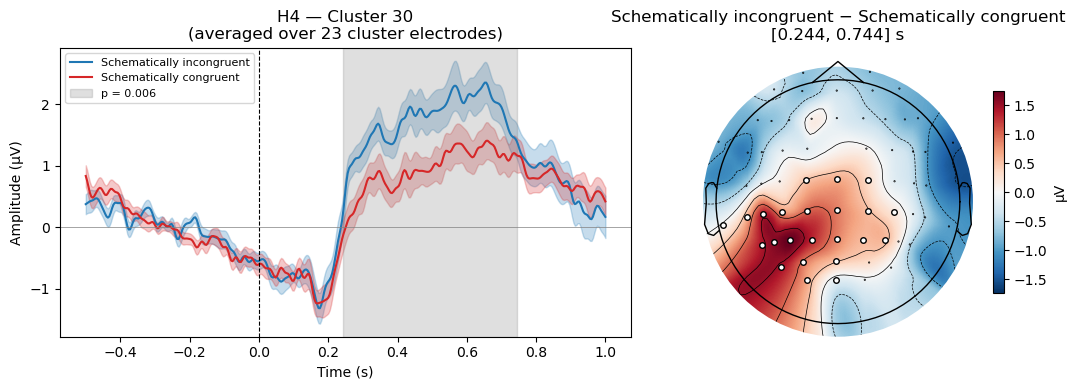

Identifying common channels ...
Identifying common channels ...


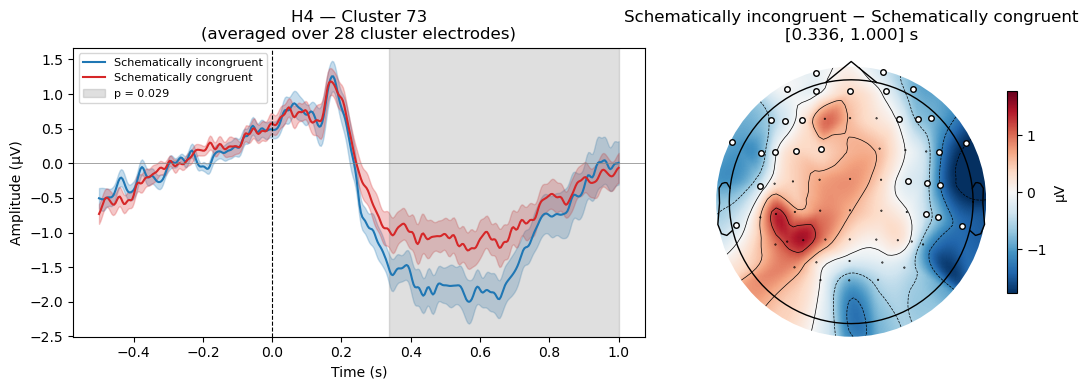

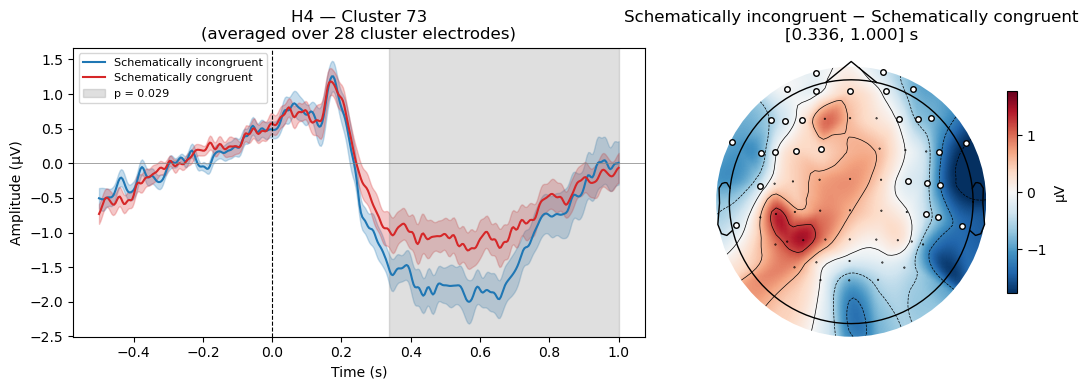

In [14]:
def plot_cluster_erp_with_topo(evokeds_cond_a, evokeds_cond_b, cluster_results, cluster_idx,
                                label_a, label_b, title):
    mask_arr = cluster_results['clusters'][cluster_idx]
    p_val = cluster_results['cluster_p_values'][cluster_idx]
    times = evokeds_cond_a[0].times

    times_idx, ch_idx = np.where(mask_arr)
    t_start, t_end = times[times_idx.min()], times[times_idx.max()]
    cluster_chs = sorted(set(ch_idx))

    # boolean mask over ALL channels, True for the ones in this cluster
    n_channels = evokeds_cond_a[0].info['nchan']
    ch_mask = np.zeros(n_channels, dtype=bool)
    ch_mask[cluster_chs] = True

    def cluster_avg_timeseries(evokeds, ch_idx_list):
        return np.array([ev.data[ch_idx_list, :].mean(axis=0) * 1e6 for ev in evokeds])

    data_a = cluster_avg_timeseries(evokeds_cond_a, cluster_chs)
    data_b = cluster_avg_timeseries(evokeds_cond_b, cluster_chs)
    mean_a, sem_a = data_a.mean(axis=0), data_a.std(axis=0, ddof=1) / np.sqrt(len(data_a))
    mean_b, sem_b = data_b.mean(axis=0), data_b.std(axis=0, ddof=1) / np.sqrt(len(data_b))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [1.4, 1]})

    axes[0].plot(times, mean_a, color='C0', label=label_a, linewidth=1.5)
    axes[0].fill_between(times, mean_a - sem_a, mean_a + sem_a, color='C0', alpha=0.25)
    axes[0].plot(times, mean_b, color='C3', label=label_b, linewidth=1.5)
    axes[0].fill_between(times, mean_b - sem_b, mean_b + sem_b, color='C3', alpha=0.25)
    axes[0].axvspan(t_start, t_end, color='gray', alpha=0.25, label=f'p = {p_val:.3f}')
    axes[0].axvline(0, color='k', linestyle='--', linewidth=0.8)
    axes[0].axhline(0, color='gray', linewidth=0.5)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (µV)')
    axes[0].set_title(f'{title}\n(averaged over {len(cluster_chs)} cluster electrodes)')
    axes[0].legend(fontsize=8)

    grand_a = mne.grand_average(evokeds_cond_a)
    grand_b = mne.grand_average(evokeds_cond_b)
    diff_data = grand_a.data - grand_b.data
    win_mask = (times >= t_start) & (times <= t_end)
    diff_topo = diff_data[:, win_mask].mean(axis=1) * 1e6

    mask_params = dict(marker='o', markerfacecolor='w', markeredgecolor='k',
                        linewidth=0, markersize=4)
    im, _ = mne.viz.plot_topomap(
        diff_topo, grand_a.info, axes=axes[1], show=False, cmap='RdBu_r',
        vlim=(-np.abs(diff_topo).max(), np.abs(diff_topo).max()),
        mask=ch_mask, mask_params=mask_params
    )
    axes[1].set_title(f'{label_a} − {label_b}\n[{t_start:.3f}, {t_end:.3f}] s')
    fig.colorbar(im, ax=axes[1], shrink=0.7, label='µV')

    plt.tight_layout()
    plt.savefig(f'cluster_erp_topo_{title.replace(" ", "_")}_{cluster_idx}.png', dpi=150)
    plt.show()
    return fig


# Example calls for your two H4 clusters
plot_cluster_erp_with_topo(evokeds['SI'], evokeds['SC'], results['H4'], 30,
                            label_a='Schematically incongruent', label_b='Schematically congruent',
                            title='H4 — Cluster 30')
plot_cluster_erp_with_topo(evokeds['SI'], evokeds['SC'], results['H4'], 73,
                            label_a='Schematically incongruent', label_b='Schematically congruent',
                            title='H4 — Cluster 73')

#### 3.4 Topomap sequences across time

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


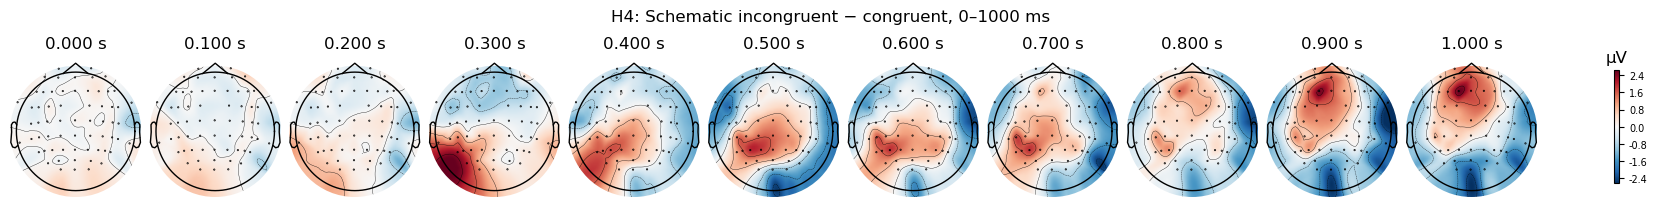

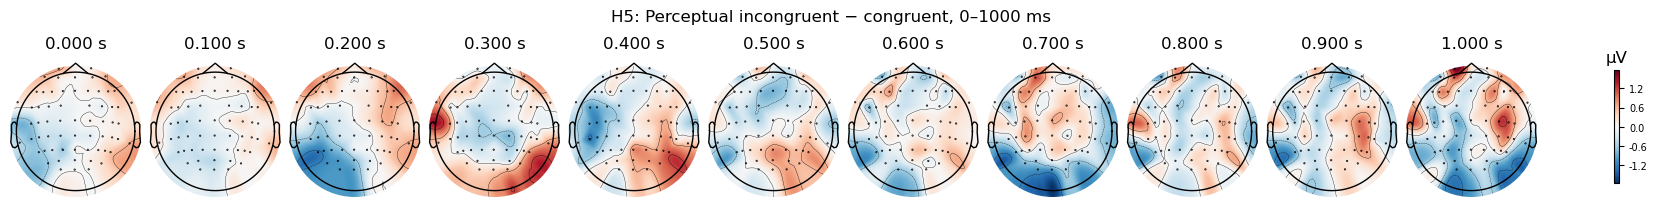

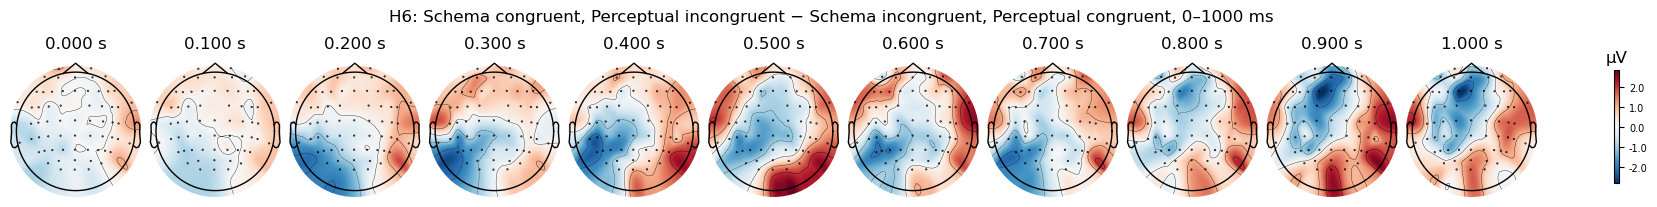

In [46]:
diff_grand_H4 = mne.grand_average(diff_waves['H4_SI_minus_SC'])  # SI - SC, all subjects
diff_grand_H5 = mne.grand_average(diff_waves['H5_PI_minus_PC'])  # PI - PC, all subjects
diff_grand_H6 = mne.grand_average(diff_waves['H6_SCPI_minus_SIPC'])  # SCPI - SIPC, all subjects


times_seq = np.arange(0.0, 1.0 + 1e-6, 0.1)  # 0, 0.1, ..., 1.0 s

fig_h4 = diff_grand_H4.plot_topomap(
    times=times_seq,
    ch_type='eeg',
    cmap='RdBu_r',
    vlim=(None, None),
    colorbar=True,
    show=False,
)
fig_h4.suptitle('H4: Schematic incongruent − congruent, 0–1000 ms')
fig_h4.savefig('H4_diff_topo_sequence_0to1000ms.png', dpi=150)
plt.show()

fig_h5 = diff_grand_H5.plot_topomap(
    times=times_seq,
    ch_type='eeg',
    cmap='RdBu_r',
    vlim=(None, None),
    colorbar=True,
    show=False,
)
fig_h5.suptitle('H5: Perceptual incongruent − congruent, 0–1000 ms')
fig_h5.savefig('H5_diff_topo_sequence_0to1000ms.png', dpi=150)
plt.show()

fig_h6 = diff_grand_H6.plot_topomap(
    times=times_seq,
    ch_type='eeg',
    cmap='RdBu_r',
    vlim=(None, None),
    colorbar=True,
    show=False,
)
fig_h6.suptitle('H6: Schema congruent, Perceptual incongruent − Schema incongruent, Perceptual congruent, 0–1000 ms')
fig_h6.savefig('H6_diff_topo_sequence_0to1000ms.png', dpi=150)
plt.show()

#### 3.5: Differences in pre-stimulus period
If we find any differences in the pre-stimulus period, this would put significant condition differences that we care about, which should occur after the stimulus presentation, into question. Thus, both tests should reveal zero significant clusters.

In [18]:
def crop_to_baseline(diff_evokeds, tmin, tmax):
    return [ev.copy().crop(tmin=tmin, tmax=tmax) for ev in diff_evokeds]

print(epochs.baseline)

baseline_tmin, baseline_tmax = epochs.baseline  

results['baseline_QC_H4'] = run_cluster_test(
    crop_to_baseline(diff_waves['H4_SI_minus_SC'], baseline_tmin, baseline_tmax),
    "Baseline QC (H4 conditions)"
)
def crop_to_baseline(diff_evokeds, tmin, tmax):
    return [ev.copy().crop(tmin=tmin, tmax=tmax) for ev in diff_evokeds]

results['baseline_QC_H5'] = run_cluster_test(
    crop_to_baseline(diff_waves['H4_SI_minus_SC'], baseline_tmin, baseline_tmax),
    "Baseline QC (H5 conditions)"
)

(-0.5, 0.0)

Baseline QC (H4 conditions): 46 clusters found, 0 significant (p < 0.05)

Baseline QC (H5 conditions): 46 clusters found, 0 significant (p < 0.05)


In [17]:
# ==========================================
# STEP 6: Save results
# ==========================================

with open(results_dir / "cluster_test_results.pkl", "wb") as f:
    pickle.dump(results, f)

summary = {
    "included_subjects": included_subjects,
    "skipped_subjects": skipped_subjects,
    "n_permutations": n_permutations,
    "alpha": alpha,
}
for hyp, res in results.items():
    summary[hyp] = {
        "n_clusters_total": len(res['clusters']),
        "significant_clusters": [
            {"cluster_index": i, "p_value": float(p)} for i, p in res['significant_clusters']
        ],
    }

with open(results_dir / "averaging_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "included_subjects": [
    "17",
    "20",
    "21",
    "22",
    "23",
    "26",
    "27",
    "30",
    "32",
    "33",
    "35",
    "36",
    "37",
    "38",
    "41",
    "42",
    "43",
    "44"
  ],
  "skipped_subjects": [
    [
      "01",
      "epochs file not found"
    ],
    [
      "02",
      "epochs file not found"
    ],
    [
      "03",
      "epochs file not found"
    ],
    [
      "04",
      "epochs file not found"
    ],
    [
      "05",
      "epochs file not found"
    ],
    [
      "06",
      "epochs file not found"
    ],
    [
      "07",
      "epochs file not found"
    ],
    [
      "08",
      "epochs file not found"
    ],
    [
      "09",
      "epochs file not found"
    ],
    [
      "10",
      "epochs file not found"
    ],
    [
      "11",
      "epochs file not found"
    ],
    [
      "12",
      "epochs file not found"
    ],
    [
      "13",
      "epochs file not found"
    ],
    [
      "14",
      "epochs file not found"
  

### Archive

#### 1. GFP plots

In [ ]:
# ==========================================
# STEP 2: Grand averages + QC waveform plots
# ==========================================


fig = mne.viz.plot_compare_evokeds(
    {'SC': grand_averages['SC'], 'SI': grand_averages['SI']},
    picks='eeg', combine='gfp', show=False,
    title="H4: Schematic congruence — grand-average GFP"
)
fig[0].savefig(results_dir / "01_gfp_SC_vs_SI.png", dpi=150)

fig = mne.viz.plot_compare_evokeds(
    {'PC': grand_averages['PC'], 'PI': grand_averages['PI']},
    picks='eeg', combine='gfp', show=False,
    title="H5: Perceptual congruence — grand-average GFP"
)
fig[0].savefig(results_dir / "02_gfp_PC_vs_PI.png", dpi=150)

fig = mne.viz.plot_compare_evokeds(
    {'SC/PI': grand_averages['Target/SC/PI'], 'SI/PC': grand_averages['Target/SI/PC']},
    picks='eeg', combine='gfp', show=False,
    title="H6: Direct contrast — SC/PI vs SI/PC"
)
fig[0].savefig(results_dir / "03_gfp_direct_contrast.png", dpi=150)

#### 2. Clusters 30 and 73 distinct?

In [ ]:

# ==========================================
# 3) Check whether clusters 30 and 73 are spatially distinct or largely the same channels
# ==========================================
def cluster_channel_set(cluster_results, cluster_idx):
    mask = cluster_results['clusters'][cluster_idx]
    _, ch_idx = np.where(mask)
    return set(ch_idx)

chs_30 = cluster_channel_set(results['H4'], 30)
chs_73 = cluster_channel_set(results['H4'], 73)
shared = chs_30 & chs_73
jaccard = len(shared) / len(chs_30 | chs_73)

print(f"Cluster 30: {len(chs_30)} channels | Cluster 73: {len(chs_73)} channels")
print(f"Shared channels: {len(shared)} | Jaccard overlap: {jaccard:.2f}")
# High Jaccard (~>0.6-0.7) + temporal overlap -> likely one continuous effect split in two
# Low Jaccard -> more likely two spatially distinct effects that happen to overlap in time